# Import Library

In [2]:
# Basic
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Text preprocessing
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer

from imblearn.over_sampling import SMOTE

from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import train_test_split

from sklearn.metrics import classification_report, confusion_matrix


In [3]:
# Download resource NLTK (jalankan sekali saja)
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /home/rafihaqul/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/rafihaqul/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /home/rafihaqul/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/rafihaqul/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

# Load Dataset

In [4]:
df = pd.read_csv('dataset_1/data.csv')
df.head(5)

,Sentence,Sentiment
0,The GeoSolutions technology will leverage Bene...,positive
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",negative
2,"For the last quarter of 2010 , Componenta 's n...",positive
3,According to the Finnish-Russian Chamber of Co...,neutral
4,The Swedish buyout firm has sold its remaining...,neutral


In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5842 entries, 0 to 5841
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Sentence   5842 non-null   object
 1   Sentiment  5842 non-null   object
dtypes: object(2)
memory usage: 91.4+ KB


,Sentence,Sentiment
count,5842,5842
unique,5322,3
top,Net sales decreased to EUR 220.5 mn from EUR 4...,neutral
freq,2,3130


In [6]:
df.isnull().sum()

Sentence     0
Sentiment    0
dtype: int64

# Exploratory Data Analysis (EDA)

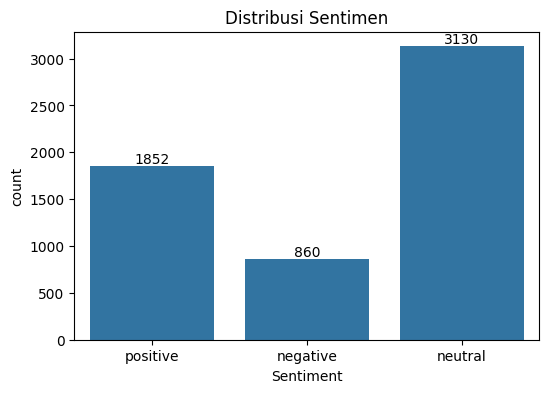

In [7]:
# Visualisasi distribusi label
plt.figure(figsize=(6,4))
sns.countplot(x='Sentiment', data=df)
plt.title("Distribusi Sentimen")

# Add count labels on each bar
ax = plt.gca()
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height,
            f'{int(height)}',
            ha="center", va="bottom")
    
plt.show()

# print(df['Sentiment'].value_counts())

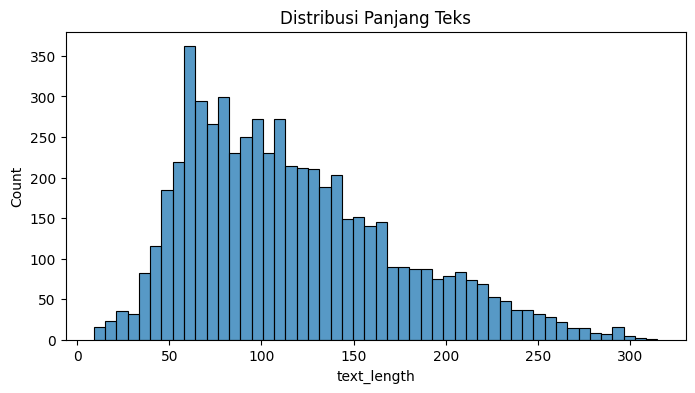

In [8]:
df['text_length'] = df['Sentence'].apply(len)

plt.figure(figsize=(8,4))
sns.histplot(df['text_length'], bins=50)
plt.title("Distribusi Panjang Teks")
plt.show()

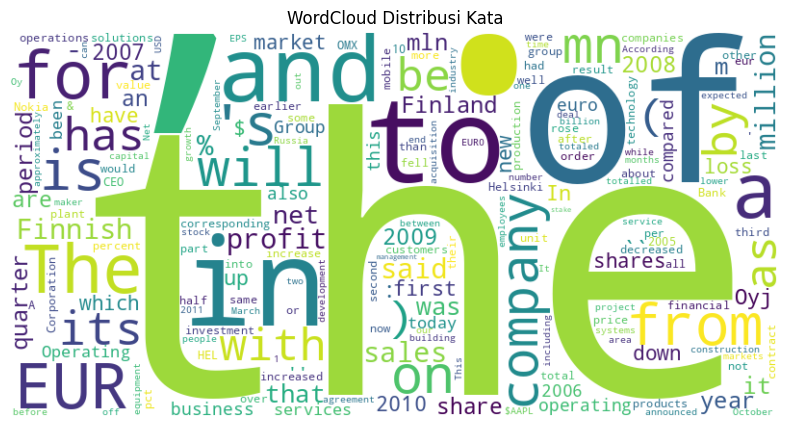

Jumlah kata unik: 15758


In [26]:
# Word Frequency
from collections import Counter

all_words = ' '.join(df['Sentence']).split()
word_freq = Counter(all_words)

word_freq_df = pd.DataFrame(word_freq.most_common(), columns=['Word', 'Frequency'])

wc = WordCloud(width=800, height=400, background_color='white')
wc.generate_from_frequencies(word_freq)

plt.figure(figsize=(10,5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud Distribusi Kata")
plt.show()

print(f"Jumlah kata unik: {len(word_freq)}")
# word_freq.most_common(10)


# Pre Processing
- stop word
- miss speling
- kata sinmgkatan
- case folding
- tokenize / encoding

In [27]:
# lowercase
df['Sentence'] = df['Sentence'].str.lower()

In [28]:
removed_log = []

# Remove URL, Mention, Angka, dan Simbol
def clean_text(text):
    # removed = re.findall(r"http\S+|@\w+|\d+", text)
    # removed_log.append(removed)
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = re.sub(r"http\S+", "", text)      # remove URL
    text = re.sub(r"@\w+", "", text)         # remove mention
    text = re.sub(r"\d+", "", text)          # remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    text = text.strip()
    return text

df['Sentence'] = df['Sentence'].apply(clean_text)
# df['Removed'] = removed_log

In [29]:
# Tokenization
df['tokens'] = df['Sentence'].apply(word_tokenize)
df.head()


,Sentence,Sentiment,text_length,tokens
0,the geosolutions technology will leverage bene...,positive,218,"[the, geosolutions, technology, will, leverage..."
1,esi on lows down to bk a real possibility,negative,55,"[esi, on, lows, down, to, bk, a, real, possibi..."
2,for the last quarter of componenta s net sales...,positive,193,"[for, the, last, quarter, of, componenta, s, n..."
3,according to the finnish russian chamber of co...,neutral,128,"[according, to, the, finnish, russian, chamber..."
4,the swedish buyout firm has sold its remaining...,neutral,135,"[the, swedish, buyout, firm, has, sold, its, r..."


In [30]:
# Stopword Removal
stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

df['tokens'] = df['tokens'].apply(remove_stopwords)

In [31]:
# Lemmatization
lemmatizer = WordNetLemmatizer()

def lemmatize_words(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

df['tokens'] = df['tokens'].apply(lemmatize_words)

In [32]:
df['clean_text'] = df['tokens'].apply(lambda x: ' '.join(x))
df.head()
# df[['text', 'clean_text']].head()

,Sentence,Sentiment,text_length,tokens,clean_text
0,the geosolutions technology will leverage bene...,positive,218,"[geosolutions, technology, leverage, benefon, ...",geosolutions technology leverage benefon gps s...
1,esi on lows down to bk a real possibility,negative,55,"[esi, low, bk, real, possibility]",esi low bk real possibility
2,for the last quarter of componenta s net sales...,positive,193,"[last, quarter, componenta, net, sale, doubled...",last quarter componenta net sale doubled eur e...
3,according to the finnish russian chamber of co...,neutral,128,"[according, finnish, russian, chamber, commerc...",according finnish russian chamber commerce maj...
4,the swedish buyout firm has sold its remaining...,neutral,135,"[swedish, buyout, firm, sold, remaining, perce...",swedish buyout firm sold remaining percent sta...


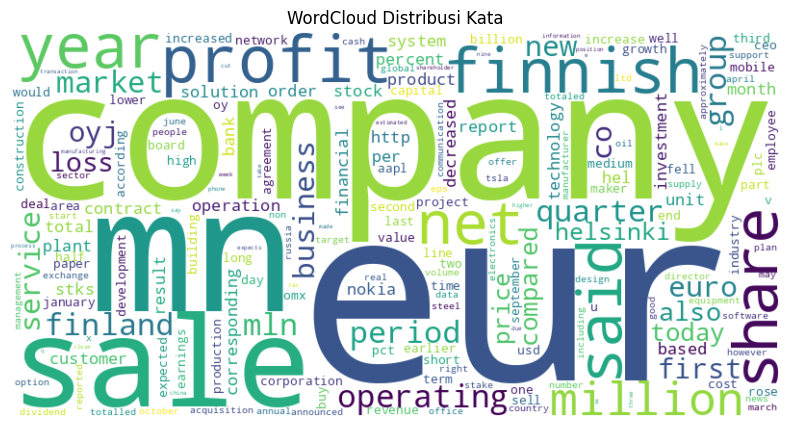

Jumlah kata unik: 9318


In [ ]:
# Word Frequency
from collections import Counter

all_words = ' '.join(df['clean_text']).split()
word_freq = Counter(all_words)

word_freq_df = pd.DataFrame(word_freq.most_common(), columns=['Word', 'Frequency'])

wc = WordCloud(width=800, height=400, background_color='white')
wc.generate_from_frequencies(word_freq)

plt.figure(figsize=(10,5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud Distribusi Kata")
# plt.savefig('wordcloud.png')
plt.show()

print(f"Jumlah kata unik: {len(word_freq)}")
# word_freq.most_common(10)


# Feature Extraction (TF-IDF)

In [45]:
tfidf = TfidfVectorizer(max_features=len(word_freq))

X = tfidf.fit_transform(df['clean_text'])
y = df['Sentiment']

print("Shape TF-IDF:", X.shape)

Shape TF-IDF: (5842, 9298)


In [46]:
print(X)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 62497 stored elements and shape (5842, 9298)>
  Coords	Values
  (0, 3273)	0.25503457390600115
  (0, 8203)	0.29264353044432023
  (0, 4636)	0.24647782556468895
  (0, 768)	0.21922388814236973
  (0, 3363)	0.23441776613277546
  (0, 7659)	0.1409416014658787
  (0, 6426)	0.19860708036914404
  (0, 4748)	0.3972141607382881
  (0, 687)	0.14409920552450567
  (0, 7291)	0.23441776613277546
  (0, 1517)	0.22235770670086202
  (0, 6122)	0.20921593655863402
  (0, 6769)	0.23441776613277546
  (0, 5325)	0.24647782556468895
  (0, 1669)	0.19196995072005055
  (0, 5435)	0.12119328652695224
  (0, 6237)	0.25503457390600115
  (0, 1499)	0.18859912878540833
  (0, 5218)	0.17799027259591835
  (1, 2625)	0.5283961007863953
  (1, 4805)	0.34651173390705564
  (1, 844)	0.5045375593419734
  (1, 6631)	0.32925044374358964
  (1, 6213)	0.48760965479197965
  (2, 4541)	0.17925654721166281
  :	:
  (5840, 7153)	0.23511631575436992
  (5840, 2662)	0.19296241836623382
  (5840

# Split Data

In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

# SMOTE

In [48]:
print("Distribusi sebelum SMOTE:")
print(y_train.value_counts())

Distribusi sebelum SMOTE:
Sentiment
neutral     2504
positive    1481
negative     688
Name: count, dtype: int64


In [49]:
smote = SMOTE(
    k_neighbors=40,
    sampling_strategy='auto',
    random_state=42
    )

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)


In [50]:
print("Distribusi setelah SMOTE:")
print(pd.Series(y_train_smote).value_counts())


Distribusi setelah SMOTE:
Sentiment
negative    2504
neutral     2504
positive    2504
Name: count, dtype: int64


# Training Random Forest

In [51]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
)

rf.fit(X_train_smote, y_train_smote)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# Evaluasi

In [52]:
y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print(cm)

              precision    recall  f1-score   support

    negative       0.19      0.16      0.17       172
     neutral       0.67      0.77      0.72       626
    positive       0.75      0.62      0.68       371

    accuracy                           0.63      1169
   macro avg       0.54      0.52      0.52      1169
weighted avg       0.62      0.63      0.62      1169

[[ 27 115  30]
 [ 98 483  45]
 [ 15 127 229]]


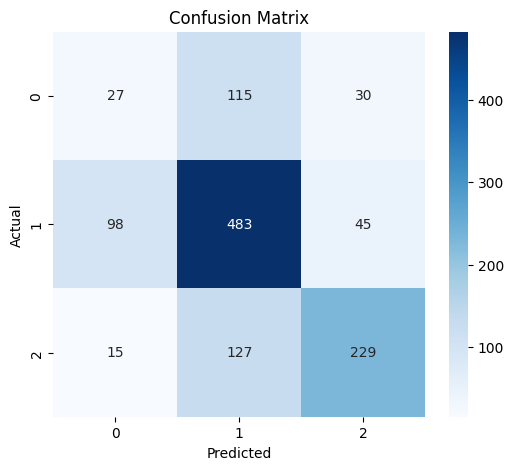

In [53]:
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
